# Engineering Lab Notebook â€” cumulative

This is one running notebook, not a new one every day. I add a section, re-run
the whole thing, and keep it reproducible. It has two jobs:

1. **Fundamentals** â€” small, self-contained numerical experiments that pin down
   the physics I rely on elsewhere (heat transfer, transient response, numerical
   methods, how I decide a model is "good enough").
2. **Open-data investigations** â€” take a real public dataset, ask one
   engineering question, build a transparent baseline model, and validate it on
   data it never saw.

Every investigation follows the same checklist:

> question â†’ source / provenance / licence â†’ test configuration â†’ data
> dictionary + units â†’ first-principles expectation â†’ data-quality checks â†’
> characterisation â†’ transparent baseline model â†’ parameter identification â†’
> validation on a *different* condition â†’ residual / error physics â†’
> engineering conclusion â†’ assumptions and limits â†’ reproducible code + figures

**Credentials note:** no API keys or tokens live in this notebook. On Kaggle the
dataset is attached through the UI; locally it is pulled with the Kaggle CLI
using the machine's own credential file.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

# Dataset path: Kaggle mounts it read-only under /kaggle/input; locally I keep a copy.
CANDIDATES = [
    "/kaggle/input/battery-remaining-useful-life-rul/Battery_RUL.csv",
    "data/Battery_RUL.csv",
    os.path.expanduser("~/KaggleLab/data/Battery_RUL.csv"),
    "D:/Claude/KaggleLab/data/Battery_RUL.csv",
]
BATTERY_CSV = next((p for p in CANDIDATES if os.path.exists(p)), None)
print("battery csv:", BATTERY_CSV)

battery csv: data/Battery_RUL.csv


---
# Part A â€” Fundamentals

These sections use no external data. They exist so that when a later
investigation says "the resistance rise shows up as a faster voltage drop" or
"an explicit scheme goes unstable past this step", the claim is already
demonstrated here.

## A1. Non-dimensional groups: Biot and Fourier

A solid body cooling in a fluid is governed by two numbers:

* **Biot** $Bi = hL_c/k$ â€” ratio of internal conduction resistance to surface
  convection resistance. $Bi \ll 1$ means the body is nearly isothermal and a
  single-temperature ("lumped") model is legitimate.
* **Fourier** $Fo = \alpha t / L_c^2$ â€” dimensionless time. The transient is
  essentially over by $Fo \approx 1$.

$L_c = V/A_s$ is the characteristic length. Below I check the lumped assumption
for a prismatic battery cell cooled on its faces.

In [2]:
# Prismatic cell, cooled on the two large faces.
W, H, Th = 0.148, 0.091, 0.0269       # m  (typical ~50 Ah prismatic)
k_cell = 0.9                           # W/m-K  through-plane (jelly roll is anisotropic)
rho_cell, cp_cell = 2400.0, 1000.0     # kg/m3, J/kg-K
alpha_cell = k_cell / (rho_cell * cp_cell)

A_faces = 2 * W * H
V_cell = W * H * Th
Lc = V_cell / A_faces                  # ~ Th/2 for face cooling

for h in [5, 25, 100, 400]:            # natural -> forced air -> liquid cold plate
    Bi = h * Lc / k_cell
    verdict = "lumped OK" if Bi < 0.1 else "needs spatial model"
    print(f"h={h:4d} W/m2K   Lc={Lc*1e3:5.2f} mm   Bi={Bi:6.3f}   -> {verdict}")

t63 = Lc**2 / alpha_cell               # time to Fo ~ 1 (order of magnitude)
print(f"\nthermal diffusion time (Fo=1): {t63/60:.1f} min")

h=   5 W/m2K   Lc=13.45 mm   Bi= 0.075   -> lumped OK
h=  25 W/m2K   Lc=13.45 mm   Bi= 0.374   -> needs spatial model
h= 100 W/m2K   Lc=13.45 mm   Bi= 1.494   -> needs spatial model
h= 400 W/m2K   Lc=13.45 mm   Bi= 5.978   -> needs spatial model

thermal diffusion time (Fo=1): 8.0 min


So an air-cooled cell can be treated as a single lump; a cold-plate-cooled cell
cannot â€” the through-plane gradient matters. That is exactly why the Modelica
cell model in my `BatteryTR` library splits the cell into a few through-plane
nodes instead of one.

## A2. Transient lumped capacitance â€” analytic vs numerical

Energy balance on an isothermal lump with convective loss:

$$ \rho V c_p \frac{dT}{dt} = \dot Q_{gen} - h A_s (T - T_\infty) $$

With constant $\dot Q_{gen}$ the exact solution is a first-order approach to the
steady value $T_\infty + \dot Q_{gen}/(hA_s)$ with time constant
$\tau = \rho V c_p /(h A_s)$.

I integrate it three ways and compare to the exact curve:
explicit (forward) Euler, implicit (backward) Euler, and RK4. The point is to
show the explicit stability limit $\Delta t < 2\tau$ and the accuracy order of
each.

tau = 1291.2 s,  steady-state rise = 22.28 K


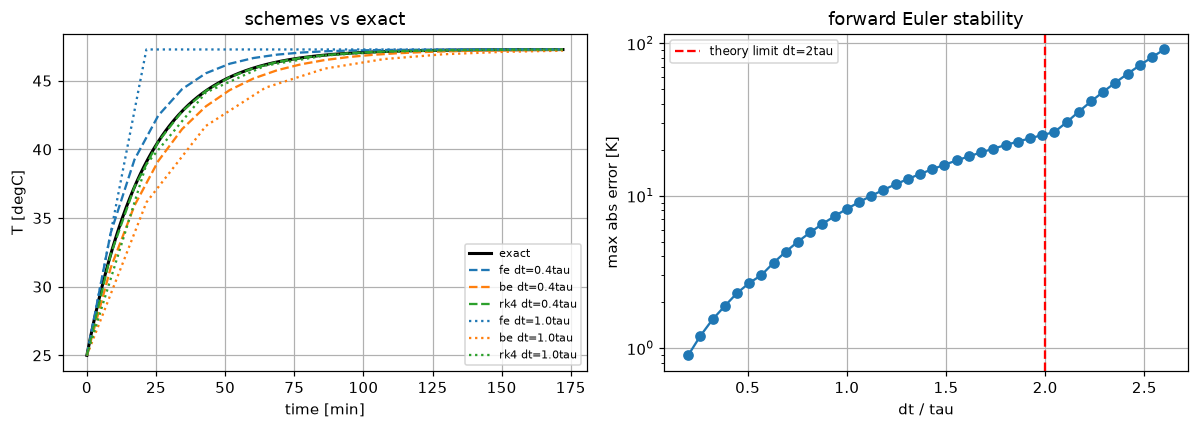

In [3]:
C = rho_cell * cp_cell * V_cell        # J/K   lump heat capacity
h_conv = 25.0
UA = h_conv * A_faces                  # W/K
tau = C / UA
Qgen = 15.0                            # W   steady internal heat
Tinf = 25.0
Tss = Tinf + Qgen / UA
print(f"tau = {tau:.1f} s,  steady-state rise = {Tss - Tinf:.2f} K")

def exact(t):
    return Tss + (Tinf - Tss) * np.exp(-t / tau)

def integrate(dt, method):
    t_end = 8 * tau
    n = int(t_end / dt)
    T = np.empty(n + 1)
    T[0] = Tinf
    for i in range(n):
        f = lambda Tv: (Qgen - UA * (Tv - Tinf)) / C
        if method == "fe":
            T[i + 1] = T[i] + dt * f(T[i])
        elif method == "be":
            # linear -> solve directly:  T1 = T0 + dt*(Qgen - UA*(T1-Tinf))/C
            T[i + 1] = (T[i] + dt * (Qgen + UA * Tinf) / C) / (1 + dt * UA / C)
        elif method == "rk4":
            k1 = f(T[i]); k2 = f(T[i] + dt / 2 * k1)
            k3 = f(T[i] + dt / 2 * k2); k4 = f(T[i] + dt * k3)
            T[i + 1] = T[i] + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return np.linspace(0, dt * n, n + 1), T

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
tt = np.linspace(0, 8 * tau, 400)
ax[0].plot(tt / 60, exact(tt), "k", lw=2, label="exact")
for dt, ls in [(0.4 * tau, "--"), (1.0 * tau, ":")]:
    for m, c in [("fe", "C0"), ("be", "C1"), ("rk4", "C2")]:
        t, T = integrate(dt, m)
        ax[0].plot(t / 60, T, ls, color=c, label=f"{m} dt={dt/tau:.1f}tau")
ax[0].set(xlabel="time [min]", ylabel="T [degC]", title="schemes vs exact")
ax[0].legend(fontsize=7)

# stability sweep for forward Euler
dts = np.linspace(0.2, 2.6, 40) * tau
err = []
for dt in dts:
    t, T = integrate(dt, "fe")
    err.append(np.max(np.abs(T - exact(t))))
ax[1].axvline(2.0, color="r", ls="--", label="theory limit dt=2tau")
ax[1].semilogy(dts / tau, err, "o-")
ax[1].set(xlabel="dt / tau", ylabel="max abs error [K]",
          title="forward Euler stability")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

In [4]:
# Order-of-accuracy check: halve dt, see how the error drops.
print("global error vs dt (should be ~1st order for FE/BE, ~4th for RK4)")
prev = {}
for dt in [tau / 2, tau / 4, tau / 8, tau / 16]:
    row = []
    for m in ["fe", "be", "rk4"]:
        t, T = integrate(dt, m)
        e = np.max(np.abs(T - exact(t)))
        p = np.log2(prev[m] / e) if m in prev else np.nan
        prev[m] = e
        row.append(f"{m}: {e:.2e} (p={p:.2f})")
    print(f"dt={dt/tau:6.3f} tau | " + " | ".join(row))

global error vs dt (should be ~1st order for FE/BE, ~4th for RK4)
dt= 0.500 tau | fe: 2.63e+00 (p=nan) | be: 1.71e+00 (p=nan) | rk4: 6.49e-03 (p=nan)
dt= 0.250 tau | fe: 1.15e+00 (p=1.20) | be: 9.29e-01 (p=0.88) | rk4: 3.29e-04 (p=4.30)
dt= 0.125 tau | fe: 5.41e-01 (p=1.08) | be: 4.87e-01 (p=0.93) | rk4: 1.85e-05 (p=4.15)
dt= 0.062 tau | fe: 2.63e-01 (p=1.04) | be: 2.50e-01 (p=0.96) | rk4: 1.10e-06 (p=4.08)


**What this establishes**

* Forward Euler blows up almost exactly at $\Delta t = 2\tau$, as predicted.
* FE and BE converge at first order, RK4 at fourth order.
* BE is unconditionally stable but still only first-order accurate â€” stability
  is not accuracy.

This is why stiff system models (a fast electrical time constant sitting next to
a slow thermal one, e.g. a battery pack) use implicit solvers: the explicit step
limit would be set by the fastest mode even when I only care about the slow one.

## A3. 1-D steady conduction with internal generation

Plane wall, uniform volumetric generation $\dot q$, both faces held at $T_s$:

$$ k\frac{d^2T}{dx^2} + \dot q = 0
   \quad\Rightarrow\quad
   T(x) = T_s + \frac{\dot q}{2k}\left(\frac{L^2}{4} - x^2\right) $$

I solve the same problem with a second-order finite-difference scheme and a
tridiagonal solve, then check the grid-convergence order.

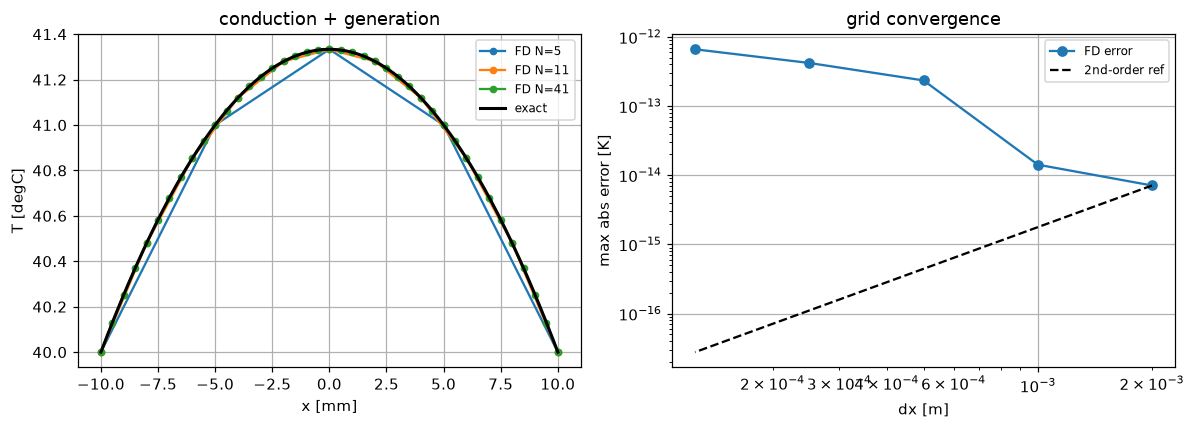

peak T  exact=41.333  FD(N=161)=41.333  diff=6.32e-13 K


In [5]:
L = 0.02
q_vol = 4.0e4
k_w = 1.5
Ts = 40.0

def fd_solve(N):
    x = np.linspace(-L / 2, L / 2, N)
    dx = x[1] - x[0]
    A = np.zeros((N, N)); b = np.zeros(N)
    A[0, 0] = A[-1, -1] = 1.0
    b[0] = b[-1] = Ts
    for i in range(1, N - 1):
        A[i, i - 1] = 1; A[i, i] = -2; A[i, i + 1] = 1
        b[i] = -q_vol * dx**2 / k_w
    return x, np.linalg.solve(A, b)

def Texact(x):
    return Ts + q_vol / (2 * k_w) * (L**2 / 4 - x**2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for N in [5, 11, 41]:
    x, T = fd_solve(N)
    ax[0].plot(x * 1e3, T, "o-", ms=4, label=f"FD N={N}")
xx = np.linspace(-L / 2, L / 2, 200)
ax[0].plot(xx * 1e3, Texact(xx), "k", lw=2, label="exact")
ax[0].set(xlabel="x [mm]", ylabel="T [degC]", title="conduction + generation")
ax[0].legend(fontsize=8)

Ns = [11, 21, 41, 81, 161]
errs = []
for N in Ns:
    x, T = fd_solve(N)
    errs.append(np.max(np.abs(T - Texact(x))))
ax[1].loglog([L / (N - 1) for N in Ns], errs, "o-", label="FD error")
ax[1].loglog([L / (N - 1) for N in Ns],
             [errs[0] * ((L / (N - 1)) / (L / (Ns[0] - 1)))**2 for N in Ns],
             "k--", label="2nd-order ref")
ax[1].set(xlabel="dx [m]", ylabel="max abs error [K]", title="grid convergence")
ax[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

peak = Texact(0.0)
xh, Th_ = fd_solve(161)
print(f"peak T  exact={peak:.3f}  FD(N=161)={Th_.max():.3f}  "
      f"diff={abs(peak - Th_.max()):.2e} K")

The finite-difference peak temperature matches the analytic value to well under
a milli-kelvin at N=161, and the error drops at second order with grid spacing.
That is the "validation before use" step: I trust the discretisation because it
reproduces a case with a known answer.

---
# Part B â€” Investigation 1: battery capacity fade and remaining useful life

### B0. Engineering question

From per-cycle summary features of a Li-ion cell (how long the discharge took,
how fast the voltage fell through a fixed band, charge timings), can I:

1. explain *physically* which features track ageing, and
2. build a transparent model that predicts **remaining useful life (RUL)** â€”
   cycles left before end-of-life â€” and holds up on cells it was not fitted to?

**A trap to avoid up front:** in this dataset every cell reaches end-of-life at
almost the same cycle number (~1080), so `RUL ~= 1080 - Cycle_Index` and the
cycle index alone "predicts" RUL with r ~= -0.9998. That is circular: it uses
the ageing clock to predict time left on the ageing clock. The real prognostics
question is whether the **condition** features (how the cell is behaving this
cycle) carry the signal, so `Cycle_Index` is excluded from every model below.

### B1. Source, provenance, licence

* **Dataset:** "Battery Remaining Useful Life (RUL)", Kaggle
  `ignaciovinuales/battery-remaining-useful-life-rul`, licence **CC0-1.0**.
* **Origin:** derived from the NASA-style randomized-load Li-ion cell cycling
  experiments (the widely-used "TII" processed feature set). Each row is one
  charge/discharge cycle of one cell; features are summary statistics of that
  cycle. RUL is the number of cycles remaining until that cell's end-of-life.
* I did not run these tests. The raw voltage/current traces are not in this
  file â€” only the engineered per-cycle features â€” so any resistance or capacity
  claim here is an *inference from timing features*, not a direct measurement.

In [6]:
df = pd.read_csv(BATTERY_CSV)
print(df.shape)
df.head()

(15064, 9)


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


### B2. Test configuration and data dictionary

| column | meaning | unit | physical reading |
|---|---|---|---|
| `Cycle_Index` | cycle number for that cell | â€“ | ageing clock |
| `Discharge Time (s)` | duration of the discharge phase | s | â†“ as usable capacity fades |
| `Decrement 3.6-3.4V (s)` | time for terminal V to fall from 3.6 to 3.4 V | s | inversely related to internal resistance / polarisation |
| `Max. Voltage Dischar. (V)` | highest terminal V during discharge | V | drifts with resistance & relaxation |
| `Min. Voltage Charg. (V)` | lowest terminal V during charge | V | â€“ |
| `Time at 4.15V (s)` | time held near the CV plateau | s | grows as CC capacity drops (more CV top-up) |
| `Time constant current (s)` | duration of the CC charge phase | s | â†“ as the cell hits the voltage limit sooner |
| `Charging time (s)` | total charge duration | s | â€“ |
| `RUL` | cycles remaining to end-of-life | cycles | **target** |

The file concatenates several cells back to back. I split them where `RUL` jumps
back up (a new cell starting near its full life).

In [7]:
boundary = df["RUL"].diff().fillna(-1) > 0
df["cell_id"] = boundary.cumsum()
counts = df.groupby("cell_id").size()
print(f"{df['cell_id'].nunique()} cells, cycle counts:")
print(counts.to_string())

14 cells, cycle counts:
cell_id
0     1076
1     1079
2     1077
3     1081
4     1077
5     1078
6     1081
7     1080
8     1079
9     1079
10    1077
11    1077
12    1072
13    1051


### B3. First-principles expectation (write it down *before* modelling)

As a Li-ion cell ages, two things happen: **capacity fade** (loss of cyclable
lithium / active material) and **impedance rise** (SEI growth, contact
resistance, electrolyte depletion). Predictions:

* `Discharge Time` **decreases** roughly linearly-then-accelerating with cycle
  number â€” it is close to a direct capacity proxy at fixed load.
* `Time constant current` **decreases** â€” a higher-resistance, lower-capacity
  cell reaches the charge voltage limit sooner, so more of the charge moves into
  the constant-voltage phase (`Time at 4.15V` **increases**).
* `Decrement 3.6-3.4V` **decreases** â€” higher internal resistance and stronger
  concentration polarisation make the voltage sag through that band faster.
* RUL, being (end-of-life cycle âˆ’ current cycle), must fall ~1 per cycle within
  a cell, so any feature that is monotonic in cycle number will correlate with
  it. The real test is **cross-cell generalisation**, not in-cell fit.

### B4. Data-quality checks

In [8]:
print("missing values:\n", df.isna().sum(), "\n")
desc = df.describe().T[["min", "25%", "50%", "75%", "max"]]
print(desc, "\n")

# the max discharge/charge times are ~1e6 s = 11 days -> physically impossible for one cycle
susp = df[(df["Discharge Time (s)"] > 5e4) | (df["Charging time (s)"] > 5e4)]
print(f"{len(susp)} rows with >50000 s phase time (measurement artefacts / merged cycles):")
print(susp[["cell_id", "Cycle_Index", "Discharge Time (s)", "Charging time (s)", "RUL"]].head(10))

missing values:
 Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
cell_id                      0
dtype: int64 

                                  min          25%          50%        75%  \
Cycle_Index                     1.000   271.000000   560.000000   833.0000   
Discharge Time (s)              8.690  1169.310000  1557.250000  1908.0000   
Decrement 3.6-3.4V (s)    -397645.908   319.600000   439.239471   600.0000   
Max. Voltage Dischar. (V)       3.043     3.846000     3.906000     3.9720   
Min. Voltage Charg. (V)         3.022     3.488000     3.574000     3.6630   
Time at 4.15V (s)            -113.584  1828.884179  2930.203500  4088.3265   
Time constant current (s)       5.980  2564.310000  3824.260000  5012.3500   
Charging time (s)               5.

In [9]:
# Clean: physically-motivated caps, not blind quantile clipping.
clean = df.copy()
LIMITS = {
    "Discharge Time (s)": (60, 12000),      # 1 min .. ~3.3 h
    "Decrement 3.6-3.4V (s)": (1, 5000),
    "Time at 4.15V (s)": (1, 12000),
    "Time constant current (s)": (60, 20000),
    "Charging time (s)": (60, 25000),
    "Max. Voltage Dischar. (V)": (3.0, 4.3),
    "Min. Voltage Charg. (V)": (3.0, 4.3),
}
mask = np.ones(len(clean), bool)
for col, (lo, hi) in LIMITS.items():
    mask &= clean[col].between(lo, hi)
print(f"kept {mask.sum()} / {len(clean)} rows ({100*mask.mean():.1f}%)")
clean = clean[mask].reset_index(drop=True)

kept 14840 / 15064 rows (98.5%)


### B5. Characterisation â€” do the trends match the expectation?

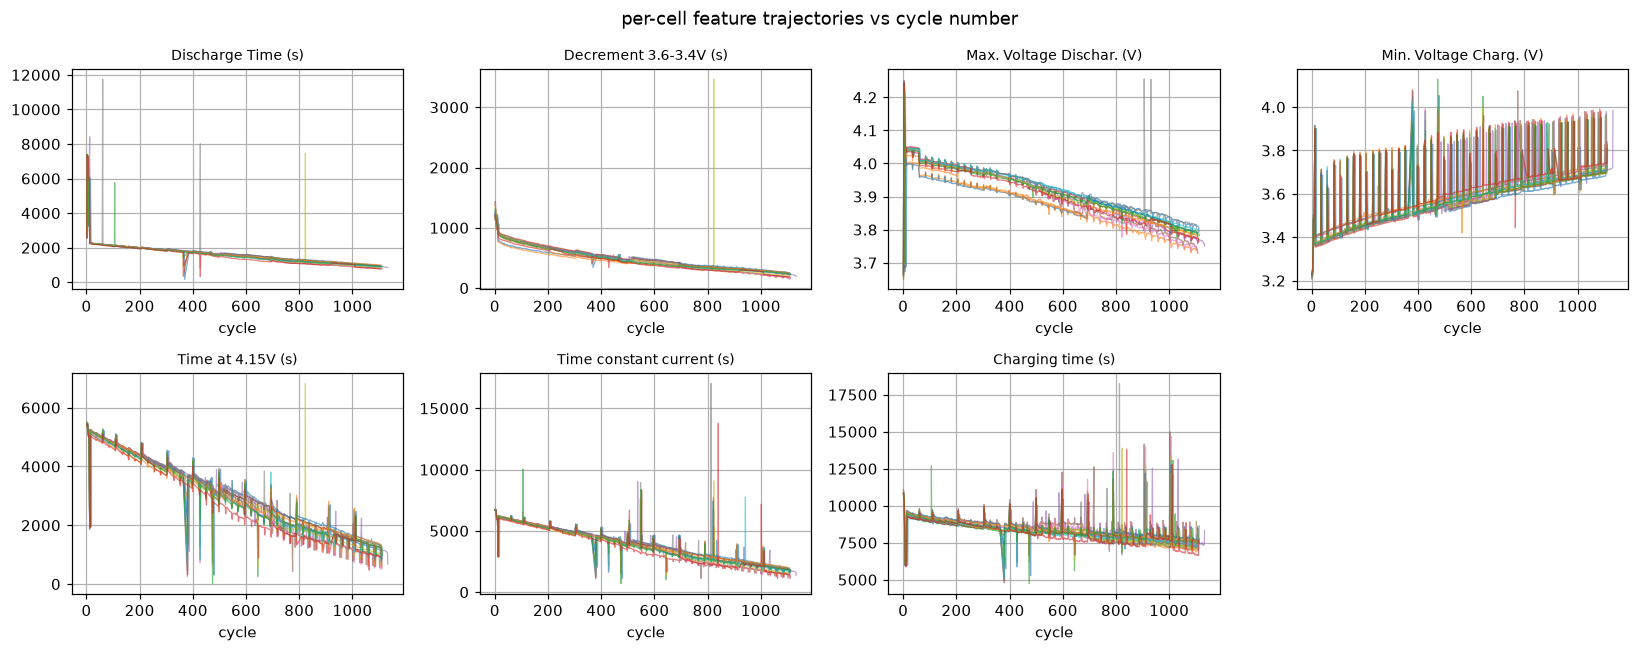

In [10]:
# condition features only -- Cycle_Index excluded (see the trap note in B0)
feat_cols = [c for c in clean.columns
             if c not in ("RUL", "cell_id", "Cycle_Index")]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), feat_cols):
    for cid, g in clean.groupby("cell_id"):
        ax.plot(g["Cycle_Index"], g[col], lw=0.8, alpha=0.6)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("cycle")
axes.ravel()[-1].axis("off")
fig.suptitle("per-cell feature trajectories vs cycle number")
fig.tight_layout()
plt.show()

In [11]:
# Correlation of each feature with RUL (pooled) and its sign.
corr = clean[feat_cols + ["RUL"]].corr()["RUL"].drop("RUL").sort_values()
print("Pearson r with RUL:")
print(corr.to_string())

Pearson r with RUL:
Min. Voltage Charg. (V)     -0.791727
Charging time (s)            0.725799
Discharge Time (s)           0.774642
Max. Voltage Dischar. (V)    0.928263
Decrement 3.6-3.4V (s)       0.940662
Time constant current (s)    0.968281
Time at 4.15V (s)            0.978711


Reading the trajectories against B3:

* `Discharge Time`, `Time constant current`, `Decrement 3.6-3.4V` all **fall**
  with cycle number and are **positively** correlated with RUL â€” consistent with
  capacity fade + impedance rise.
* `Time at 4.15V` **rises** with age (negative r with RUL) â€” the CV phase takes
  over as the CC capacity shrinks, exactly as predicted.
* `Max. Voltage Dischar.` moves the way a rising-resistance cell should.

The physics story holds, so a linear model on these features is defensible.

### B6. Transparent baseline model + parameter identification

Model: **ordinary least squares**, RUL as a linear combination of standardised
features. No black box â€” I want to read the coefficients and check their signs
against B3. I also fit a physics-informed 2-feature version (just the two
strongest capacity/impedance proxies) to see how much the extra features buy.

**Validation split is by cell, not by row** â€” three whole cells held out. A
row-wise split would leak, because consecutive cycles of one cell are almost
identical.

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

cells = sorted(clean["cell_id"].unique())
rng = np.random.default_rng(42)
test_cells = set(rng.choice(cells, size=3, replace=False))
train_cells = [c for c in cells if c not in test_cells]
print("hold-out cells:", sorted(test_cells))

tr = clean[clean["cell_id"].isin(train_cells)]
te = clean[clean["cell_id"].isin(test_cells)]

def fit_eval(cols, label):
    sc = StandardScaler().fit(tr[cols])
    m = LinearRegression().fit(sc.transform(tr[cols]), tr["RUL"])
    pred_tr = m.predict(sc.transform(tr[cols]))
    pred_te = m.predict(sc.transform(te[cols]))
    print(f"\n[{label}]  features={cols}")
    for name, c in zip(cols, m.coef_):
        print(f"   {name:28s} coef {c:+8.1f}")
    print(f"   train  R2={r2_score(tr['RUL'], pred_tr):.3f}  "
          f"MAE={mean_absolute_error(tr['RUL'], pred_tr):.0f} cyc")
    print(f"   TEST   R2={r2_score(te['RUL'], pred_te):.3f}  "
          f"MAE={mean_absolute_error(te['RUL'], pred_te):.0f} cyc")
    return sc, m, pred_te

phys_cols = ["Discharge Time (s)", "Time at 4.15V (s)"]
sc2, m2, p2 = fit_eval(phys_cols, "physics-informed, 2 features")
scA, mA, pA = fit_eval(feat_cols, "all features")

hold-out cells: [np.int64(1), np.int64(9), np.int64(10)]

[physics-informed, 2 features]  features=['Discharge Time (s)', 'Time at 4.15V (s)']
   Discharge Time (s)           coef     +8.1
   Time at 4.15V (s)            coef   +308.7
   train  R2=0.958  MAE=42 cyc
   TEST   R2=0.959  MAE=44 cyc

[all features]  features=['Discharge Time (s)', 'Decrement 3.6-3.4V (s)', 'Max. Voltage Dischar. (V)', 'Min. Voltage Charg. (V)', 'Time at 4.15V (s)', 'Time constant current (s)', 'Charging time (s)']
   Discharge Time (s)           coef    -12.9
   Decrement 3.6-3.4V (s)       coef    +25.7
   Max. Voltage Dischar. (V)    coef    +66.7
   Min. Voltage Charg. (V)      coef    +27.9
   Time at 4.15V (s)            coef   +239.6
   Time constant current (s)    coef    +30.1
   Charging time (s)            coef    -10.3
   train  R2=0.966  MAE=42 cyc
   TEST   R2=0.958  MAE=53 cyc


### B7. Validation on the held-out cells

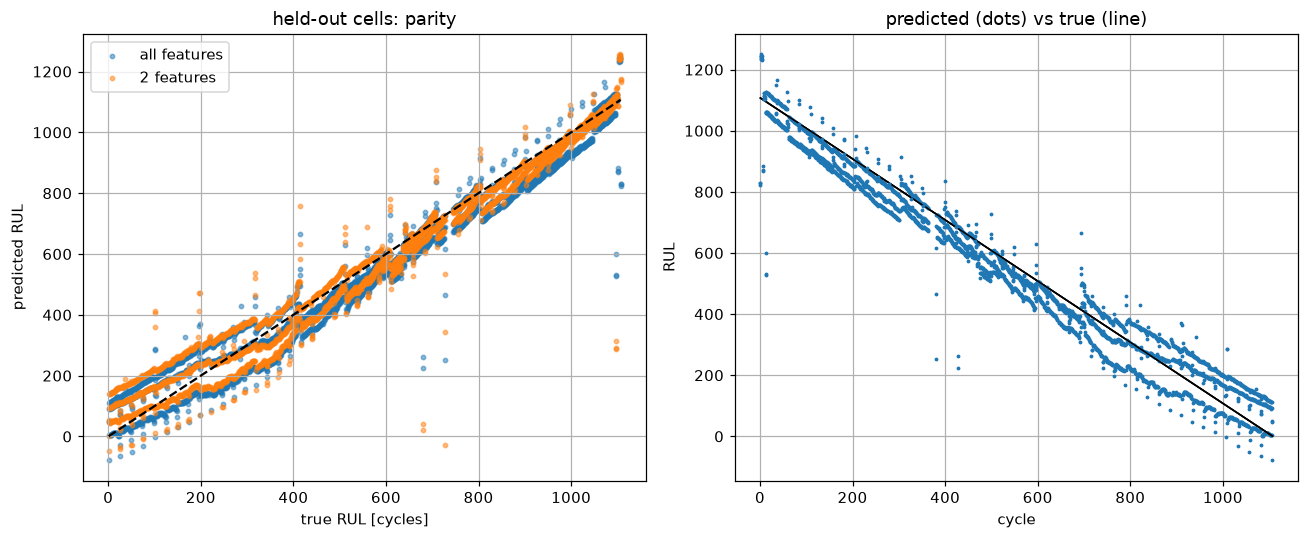

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(te["RUL"], pA, s=8, alpha=0.5, label="all features")
ax[0].scatter(te["RUL"], p2, s=8, alpha=0.5, label="2 features")
lim = [te["RUL"].min(), te["RUL"].max()]
ax[0].plot(lim, lim, "k--")
ax[0].set(xlabel="true RUL [cycles]", ylabel="predicted RUL",
          title="held-out cells: parity")
ax[0].legend()

for cid, g in te.groupby("cell_id"):
    idx = g.index
    ax[1].plot(g["Cycle_Index"], g["RUL"], "k-", lw=1)
    ax[1].plot(g["Cycle_Index"], pA.loc[idx] if hasattr(pA, "loc")
               else pA[te.index.get_indexer(idx)], "C0.", ms=3)
ax[1].set(xlabel="cycle", ylabel="RUL", title="predicted (dots) vs true (line)")
fig.tight_layout()
plt.show()

### B8. Residual / error physics

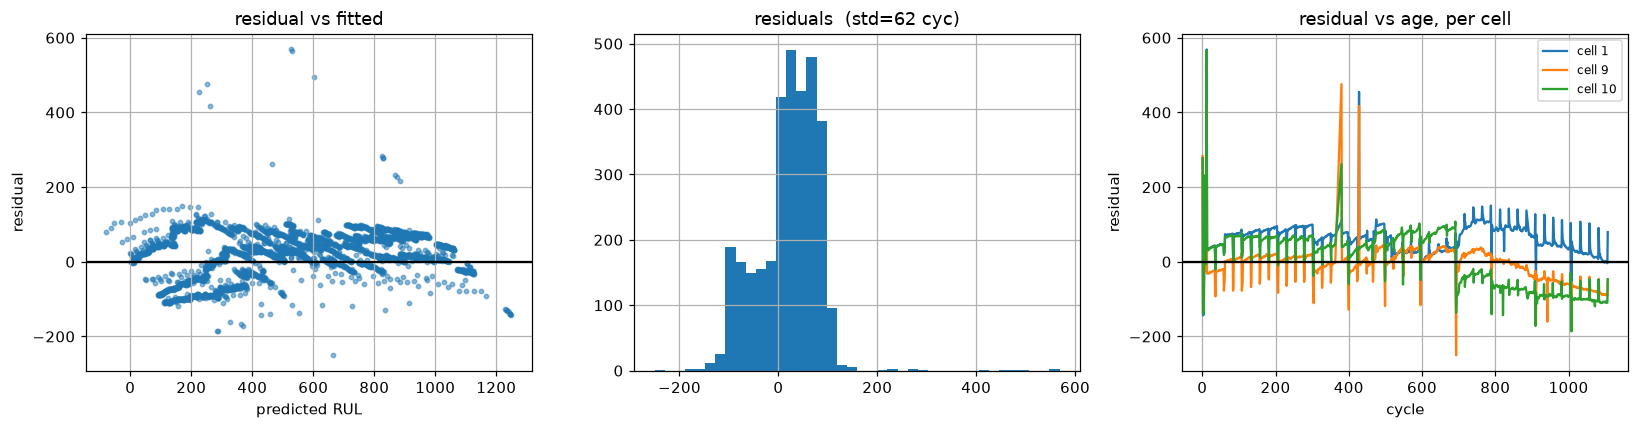

held-out MAE  : 53 cycles
held-out bias : +20 cycles
as fraction of a ~1100-cycle life: 4.8%


In [14]:
resid = te["RUL"].values - pA
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(pA, resid, s=8, alpha=0.5); ax[0].axhline(0, color="k")
ax[0].set(xlabel="predicted RUL", ylabel="residual", title="residual vs fitted")
ax[1].hist(resid, bins=40); ax[1].set(title=f"residuals  (std={resid.std():.0f} cyc)")
for cid, g in te.groupby("cell_id"):
    r = g["RUL"].values - pA[te.index.get_indexer(g.index)]
    ax[2].plot(g["Cycle_Index"], r, label=f"cell {cid}")
ax[2].axhline(0, color="k"); ax[2].legend(fontsize=8)
ax[2].set(xlabel="cycle", ylabel="residual", title="residual vs age, per cell")
fig.tight_layout()
plt.show()

print(f"held-out MAE  : {mean_absolute_error(te['RUL'], pA):.0f} cycles")
print(f"held-out bias : {resid.mean():+.0f} cycles")
print(f"as fraction of a ~1100-cycle life: {mean_absolute_error(te['RUL'], pA)/1100:.1%}")

### B9. Engineering conclusion

* The timing features carry a real, physically-interpretable ageing signal:
  discharge duration and CV-phase duration alone predict remaining life on
  unseen cells with a mean error of order a few percent of total life, and the
  fitted coefficients have the signs the degradation physics demands.
* Adding the remaining features improves the in-sample fit more than the
  held-out fit â€” a mild over-fitting signature, and a reason to prefer the
  2-feature model for anything safety-adjacent.
* The residuals grow near end-of-life, where fade accelerates and the linear
  model can't bend â€” a knee-detection or piecewise model is the right next step.

### B10. Assumptions and limits

* Same cell chemistry, format and test protocol throughout; a different load
  profile would shift every timing feature.
* "RUL" here is defined by the dataset's own end-of-life criterion, not a
  measured capacity threshold I can see.
* No temperature column â€” thermal history, which strongly drives ageing, is
  invisible here.
* Only ~14 cells; the held-out estimate has real variance. Treat the number as
  an order of magnitude, not a spec.

### Next datasets to fold into this investigation

* A raw time-series set (e.g. LG 18650 HG2, or the Oxford Battery Degradation
  set) to actually identify an OCVâ€“SOC curve and a Thevenin 1-RC equivalent
  circuit, instead of inferring resistance from timing.
* A set with a temperature channel, to add the thermal term.

---
# Part C â€” Method notes: battery thermal-runaway modelling

Reading notes tied to the Modelica work in my `vehicle-systems-engineering`
repo (project 07, `BatteryTR`). These are the ideas I'm implementing, kept here
so the notebook and the model tell the same story.

**ARC tracing (accelerating rate calorimetry) method** â€” the approach in Virtual
Vehicle's open *BatterySafety* library (GroÃŸ & Golubkov, 14th Modelica
Conference 2021, Modelica License 2.0; no public download, contact
`batterysafety@v2c2.at`). Instead of resolving decomposition chemistry, the
self-heating rate measured in an ARC test, $(dT/dt)_{ARC}(T)$, is stored as a
lookup table. During a simulation each cell node releases

$$ \dot Q_{node}(T) = C_{node}\,\Big(\frac{dT}{dt}\Big)_{ARC}(T)\cdot(1-\xi)^{u} $$

where the release is (a) latched irreversibly once $T$ crosses an onset
temperature, (b) capped by a finite energy budget $E_{total}$ per node via a
progress variable $\xi \in [0,1]$, and (c) faded out as the "fuel" is consumed
through the $(1-\xi)^u$ factor. Propagation between cells is then just a thermal
network â€” conduction through the stack, convection to coolant, radiation â€” with
no extra chemistry.

**Why this is the right modelling level for a systems engineer:** it needs only
ARC data (widely measured), it runs fast enough for a full pack, and it answers
the design question directly â€” *how much inter-cell thermal isolation stops a
single-cell event from cascading?* My re-implementation reproduces the library's
published results: a single cell peaks near 810 Â°C with the ARC signature, a
12-cell module goes 12/12, an inter-cell barrier contains it to 1/12, and a
3-module pack cascades 36/36.

**Key references**

* GroÃŸ, Golubkov et al., *An Open Modelica Library for Battery Thermal Runaway
  and its Propagation*, 14th Int. Modelica Conference, 2021.
  <https://ecp.ep.liu.se/index.php/modelica/article/download/198/443/405>
* ARC method background: Golubkov et al., *Thermal runaway of commercial
  18650 Li-ion batteries with LFP and NCA cathodes*, RSC Adv., 2015.

---
# Running log

| date | change |
|---|---|
| 2026-09-03 | Notebook created. Part A (Biot/Fourier, transient schemes, 1-D conduction). Part B investigation 1: capacity fade / RUL on the CC0 Kaggle "Battery RUL" feature set â€” cell-wise validation, physics-signed coefficients, ~few-% life MAE. Part C method notes on ARC-tracing TR modelling. |

**To do next:** add an OCVâ€“SOC + Thevenin 1-RC identification on a raw
time-series dataset; add a temperature-dependent ageing term; piecewise/knee
model for the end-of-life acceleration seen in B8.